<a href="https://colab.research.google.com/github/AngieVenta/AngieVenta/blob/main/DS_C6_SC1_GloriaAngelicaVenta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto | Optimizar un modelo para predecir las cancelaciones en reservaciones hoteleras

**Objetivo:** Producir un modelo de clasificación optimizado que estime las probabilidades de cancelación de reservaciones hoteleras, minimizando el error de clasificación.


In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Feature selection
from sklearn.feature_selection import RFECV

# Class imbalance
from imblearn.over_sampling import SMOTE

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Carga y exploración inicial del dataset

In [2]:
# Load dataset
df = pd.read_csv('hotels.csv')

print(f'Shape: {df.shape}')
print(f'\nFirst rows:')
df.head()

# General info
df.info()

# Descriptive statistics
df.describe()

# Missing values
missing = df.isnull().sum()
missing[missing > 0]

Shape: (119390, 32)

First rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nu

,0
children,4
country,488
agent,16340
company,112593


## 2. Detección de desbalance de clases

Class distribution (absolute):
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Class distribution (%):
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


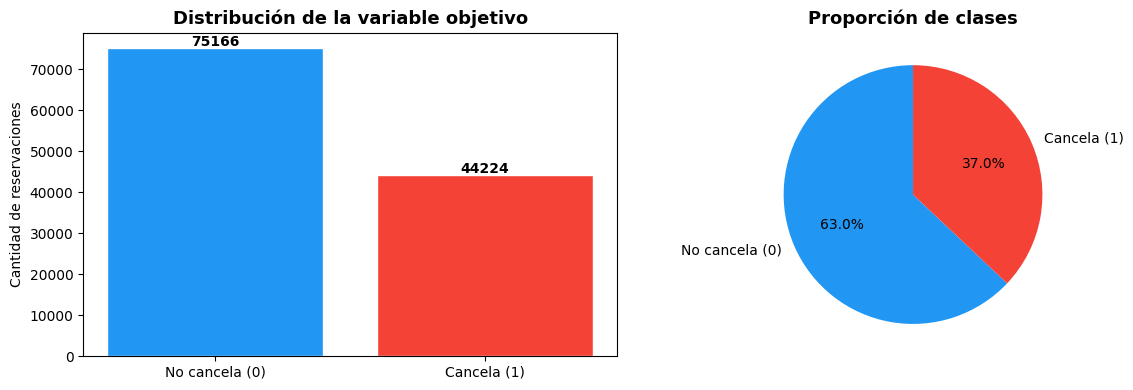


Ratio mayoría/minoría: 1.70


In [3]:
# Class distribution
class_counts = df['is_canceled'].value_counts()
class_pct = df['is_canceled'].value_counts(normalize=True) * 100

print('Class distribution (absolute):')
print(class_counts)
print('\nClass distribution (%):')
print(class_pct.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No cancela (0)', 'Cancela (1)'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Distribución de la variable objetivo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de reservaciones')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['No cancela (0)', 'Cancela (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Imbalance ratio
ratio = class_counts[0] / class_counts[1]
print(f'\nRatio mayoría/minoría: {ratio:.2f}')


Interpretación: El dataset presenta un desbalance moderado con 63% de no cancelaciones y 37% de cancelaciones (ratio ~1.7:1). Esto no es un caso extremo de imbalance, pero sí suficiente para que el modelo pueda sesgarse hacia la clase mayoritaria. Por eso se justifica aplicar SMOTE solo en el entrenamiento y/o usar técnicas de balanceo de clases para mejorar la detección de cancelaciones.

## 3. Preprocesamiento y feature engineering

In [4]:
# Preserve reservation ID for final output
df['reservation_id'] = df.index

# Drop leakage columns
# 'reservation_status' directly encodes the outcome (Check-Out / Canceled / No-Show)
# 'reservation_status_date' is also post-hoc information
df_model = df.drop(columns=['reservation_status', 'reservation_status_date'])

# Handle missing values
df_model['children'] = df_model['children'].fillna(0)
df_model['country'] = df_model['country'].fillna('Unknown')
df_model['agent'] = df_model['agent'].fillna(0)
# 'company' has ~94% missing → drop the column
df_model = df_model.drop(columns=['company'])

# Feature engineering
# Total nights stayed
df_model['total_nights'] = df_model['stays_in_weekend_nights'] + df_model['stays_in_week_nights']

# Total guests
df_model['total_guests'] = df_model['adults'] + df_model['children'] + df_model['babies']

# Room mismatch: reserved ≠ assigned room type
df_model['room_mismatch'] = (df_model['reserved_room_type'] != df_model['assigned_room_type']).astype(int)

# Has agent flag
df_model['has_agent'] = (df_model['agent'] > 0).astype(int)

# Map arrival month to numeric
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df_model['arrival_month_num'] = df_model['arrival_date_month'].map(month_map)

print('Feature engineering complete.')
print(f'Columns after engineering: {df_model.shape[1]}')

Feature engineering complete.
Columns after engineering: 35


In [5]:
# Encode categorical variables
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('arrival_date_month')  # already encoded as numeric
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Drop original month column
df_model = df_model.drop(columns=['arrival_date_month'])

print('Encoding complete.')

Categorical columns to encode: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Encoding complete.


## 4. Análisis de correlaciones

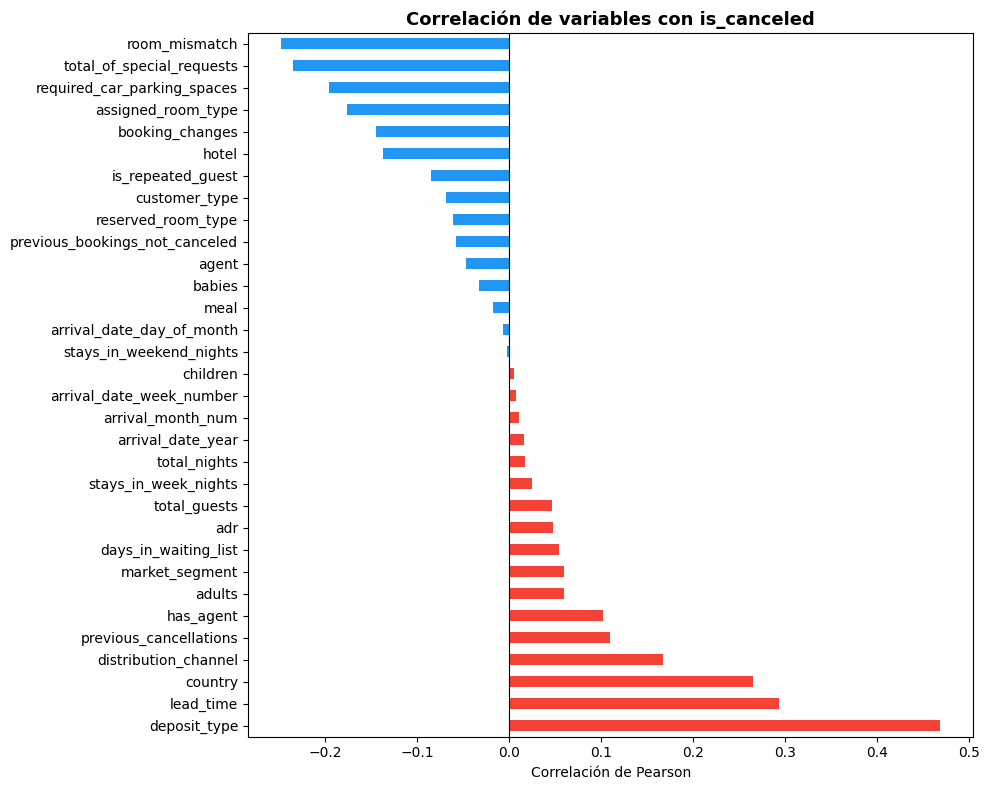


Top correlaciones positivas (predicen cancelación):
deposit_type              0.468634
lead_time                 0.293123
country                   0.264738
distribution_channel      0.167600
previous_cancellations    0.110133
has_agent                 0.102068
adults                    0.060017
market_segment            0.059338
days_in_waiting_list      0.054186
Name: is_canceled, dtype: float64

Top correlaciones negativas (predicen NO cancelación):
previous_bookings_not_canceled   -0.057358
reserved_room_type               -0.061282
customer_type                    -0.068140
is_repeated_guest                -0.084793
hotel                            -0.136531
booking_changes                  -0.144381
assigned_room_type               -0.176028
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
room_mismatch                    -0.247770
Name: is_canceled, dtype: float64


In [6]:
corr_target = df_model.drop(columns=['reservation_id']).corr()['is_canceled'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_target.drop('is_canceled').values]
corr_target.drop('is_canceled').plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de variables con is_canceled', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print('\nTop correlaciones positivas (predicen cancelación):')
print(corr_target[corr_target > 0.05].drop('is_canceled'))
print('\nTop correlaciones negativas (predicen NO cancelación):')
print(corr_target[corr_target < -0.05])

## 5. Construcción del conjunto de entrenamiento y prueba

In [7]:
# Define features and target
X = df_model.drop(columns=['is_canceled', 'reservation_id'])
y = df_model['is_canceled']

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'\nClass distribution in train: {y_train.value_counts(normalize=True).round(4).to_dict()}')
print(f'Class distribution in test:  {y_test.value_counts(normalize=True).round(4).to_dict()}')


Training set: 95,512 samples
Test set:     23,878 samples

Class distribution in train: {0: 0.6296, 1: 0.3704}
Class distribution in test:  {0: 0.6296, 1: 0.3704}


In [8]:
# Apply SMOTE only to training set to handle moderate imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Training set after SMOTE: {X_train_res.shape[0]:,} samples')
print(f'Class distribution after SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}')


Training set after SMOTE: 120,266 samples
Class distribution after SMOTE: {0: 60133, 1: 60133}


## 6. Modelo Base (Dummy Classifier)

In [9]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_res, y_train_res)
y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = np.zeros(len(y_test))  # dummy always predicts 0

f1_dummy = f1_score(y_test, y_pred_dummy)
print(f'=== MODELO BASE (DummyClassifier - most_frequent) ===')
print(f'F1-score (test): {f1_dummy:.4f}')


=== MODELO BASE (DummyClassifier - most_frequent) ===
F1-score (test): 0.0000


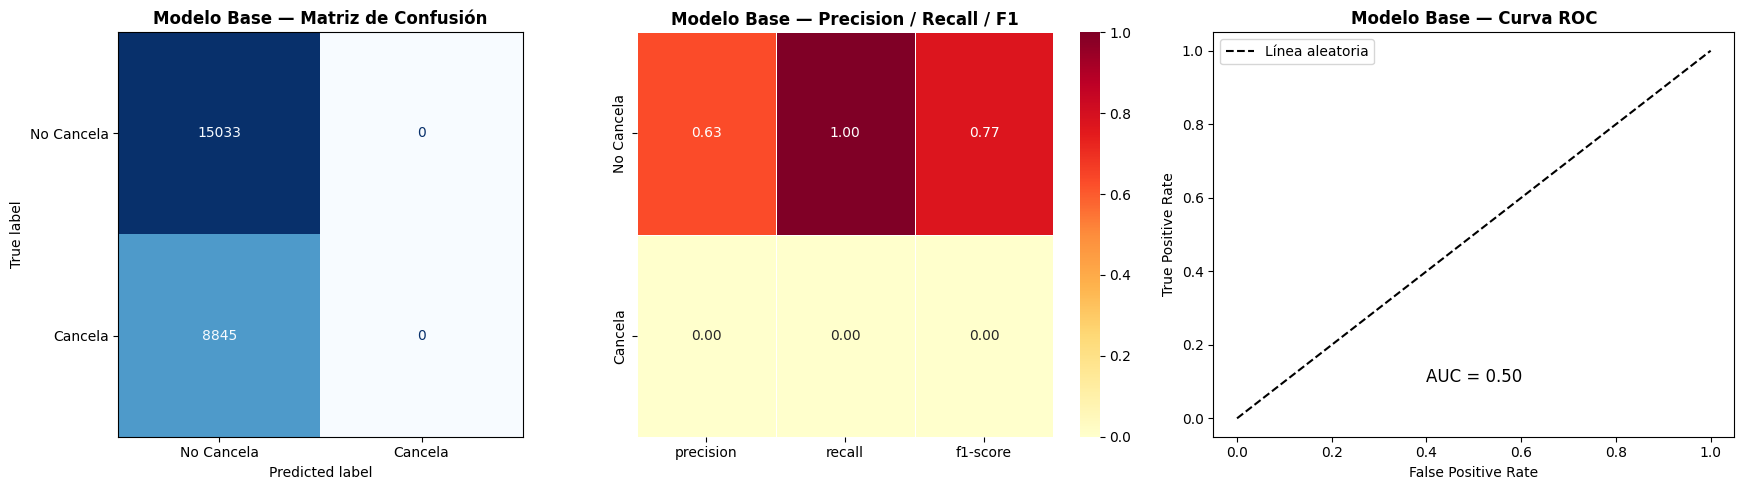

              precision    recall  f1-score   support

  No Cancela       0.63      1.00      0.77     15033
     Cancela       0.00      0.00      0.00      8845

    accuracy                           0.63     23878
   macro avg       0.31      0.50      0.39     23878
weighted avg       0.40      0.63      0.49     23878


Interpretación: El modelo base siempre predice la clase mayoritaria (no cancela). Por eso F1=0 para la clase positiva y AUC=0.50 (equivalente a adivinar al azar). Este es el umbral mínimo que el modelo optimizado debe superar.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm_dummy = confusion_matrix(y_test, y_pred_dummy)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=['No Cancela', 'Cancela'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Modelo Base — Matriz de Confusión', fontweight='bold')

# Classification report heatmap
report_dummy = classification_report(y_test, y_pred_dummy,
                                     target_names=['No Cancela', 'Cancela'], output_dict=True)
report_df_dummy = pd.DataFrame(report_dummy).T.iloc[:2, :3]
sns.heatmap(report_df_dummy.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Modelo Base — Precision / Recall / F1', fontweight='bold')

# ROC Curve (dummy)
fpr_d, tpr_d, _ = roc_curve(y_test, np.zeros(len(y_test)))
axes[2].plot([0, 1], [0, 1], 'k--', label='Línea aleatoria')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Modelo Base — Curva ROC', fontweight='bold')
axes[2].legend()
axes[2].text(0.4, 0.1, 'AUC = 0.50', fontsize=12)

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_dummy, target_names=['No Cancela', 'Cancela']))
print('\nInterpretación: El modelo base siempre predice la clase mayoritaria (no cancela). '
      'Por eso F1=0 para la clase positiva y AUC=0.50 (equivalente a adivinar al azar). '
      'Este es el umbral mínimo que el modelo optimizado debe superar.')

**Interpretación del modelo base:** El DummyClassifier predice siempre "no cancela", logrando accuracy del 63% pero **F1-score de 0.00 para cancelaciones**. La curva ROC es diagonal (AUC = 0.50), equivalente a clasificación aleatoria. Este modelo es inútil para el negocio porque no identifica ninguna cancelación.

## 7. Modelo Optimizado — Random Forest con RandomizedSearchCV

In [11]:
# Justificación del modelo: Random Forest
# - Robusto a outliers y variables de escala mixta
# - Maneja bien variables categóricas codificadas
# - Proporciona probabilidades calibradas para el CSV de entregable
# - Permite  feature importance para interpretabilidad de negocio
#
# Se realizará RandomizedSearchCV con scoring=f1 para optimizar los hiperparámetros.
param_distributions = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=12,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_res, y_train_res)

best_rf = search.best_estimator_
print('Mejores parámetros encontrados:')
print(search.best_params_)

# Usamos el mejor modelo encontrado
best_rf.fit(X_train_res, y_train_res)

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"=== RANDOM FOREST OPTIMIZADO ===")
print(f"F1-score  (test): {f1_rf:.4f}")
print(f"ROC-AUC   (test): {auc_rf:.4f}")
print(f"Mejora vs modelo base: +{f1_rf - f1_dummy:.4f} en F1-score")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parámetros encontrados:
{'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced'}
=== RANDOM FOREST OPTIMIZADO ===
F1-score  (test): 0.8560
ROC-AUC   (test): 0.9589
Mejora vs modelo base: +0.8560 en F1-score


## 8. Análisis de importancia de variables

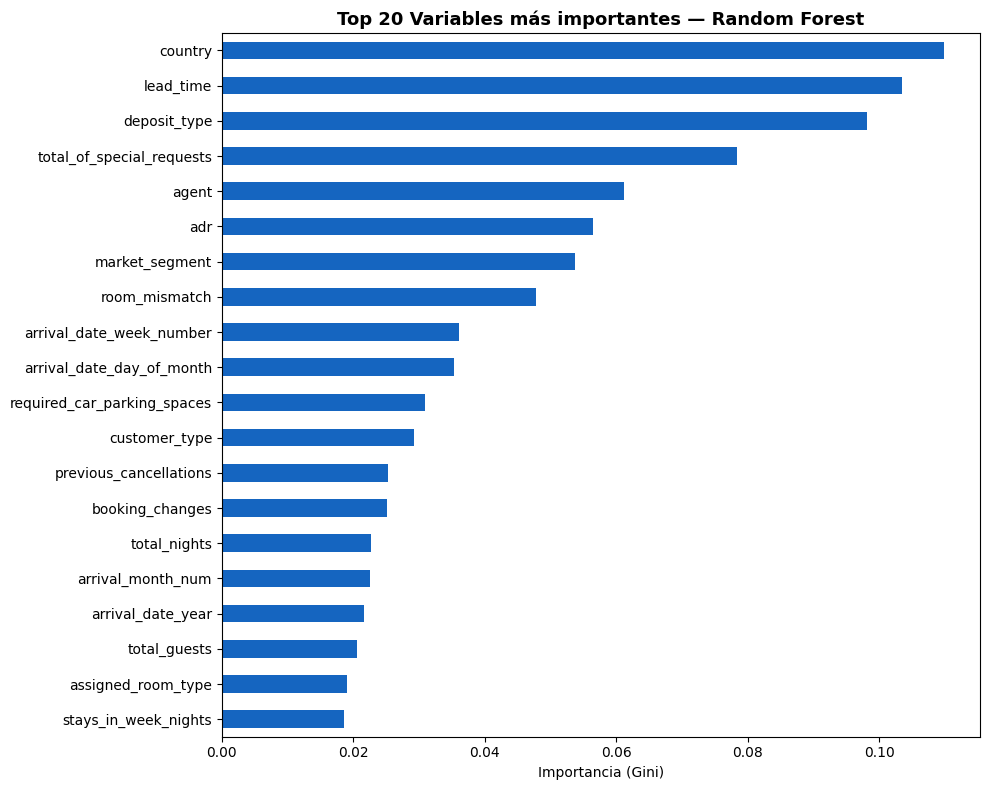

Variables con mayor importancia predictiva:
country                      0.1098
lead_time                    0.1034
deposit_type                 0.0982
total_of_special_requests    0.0783
agent                        0.0612
adr                          0.0564
market_segment               0.0537
room_mismatch                0.0477
arrival_date_week_number     0.0361
arrival_date_day_of_month    0.0353
dtype: float64


In [12]:
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', ax=ax, color='#1565C0')
ax.invert_yaxis()
ax.set_title('Top 20 Variables más importantes — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

print('Variables con mayor importancia predictiva:')
print(feat_imp.head(10).round(4))

## 9. Discrimination Threshold — Punto de corte óptimo

Threshold por defecto (0.50): F1 = 0.8560
Threshold óptimo (0.45):    F1 = 0.8585


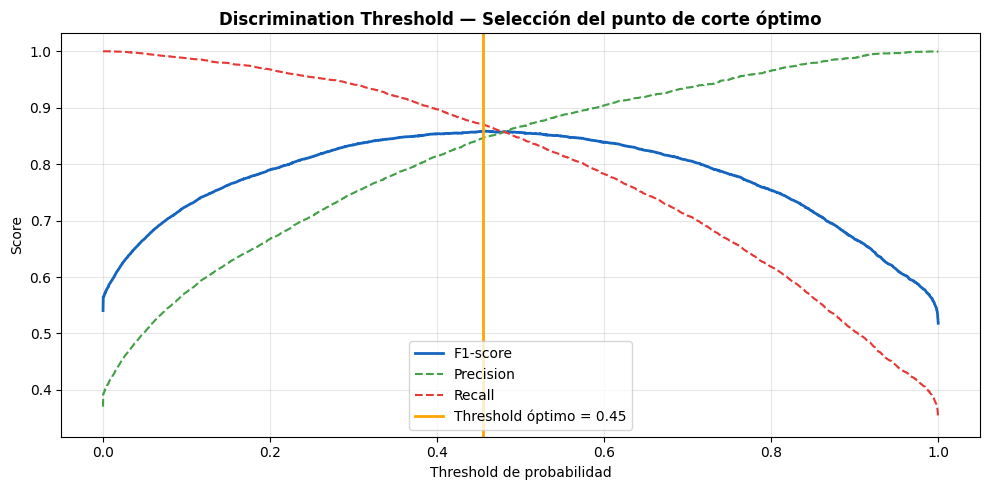


 Se usa threshold óptimo (0.45) por mayor F1.


In [13]:
# Find optimal threshold by maximizing F1-score
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)
f1_scores_thresh = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh_idx = np.argmax(f1_scores_thresh)
best_threshold = thresholds[best_thresh_idx]

print(f'Threshold por defecto (0.50): F1 = {f1_rf:.4f}')

# Apply optimal threshold
y_pred_thresh = (y_prob_rf >= best_threshold).astype(int)
f1_thresh = f1_score(y_test, y_pred_thresh)
print(f'Threshold óptimo ({best_threshold:.2f}):    F1 = {f1_thresh:.4f}')

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores_thresh[:-1], color='#1565C0', linewidth=2, label='F1-score')
ax.plot(thresholds, precision[:-1], color='#43A047', linewidth=1.5, linestyle='--', label='Precision')
ax.plot(thresholds, recall[:-1], color='#E53935', linewidth=1.5, linestyle='--', label='Recall')
ax.axvline(best_threshold, color='orange', linewidth=2, label=f'Threshold óptimo = {best_threshold:.2f}')
ax.set_xlabel('Threshold de probabilidad')
ax.set_ylabel('Score')
ax.set_title('Discrimination Threshold — Selección del punto de corte óptimo', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Use the best configuration
if f1_thresh > f1_rf:
    y_pred_final = y_pred_thresh
    print(f'\n Se usa threshold óptimo ({best_threshold:.2f}) por mayor F1.')
else:
    y_pred_final = y_pred_rf
    print(f'\n Se mantiene threshold por defecto (0.50).')

## 10. Evaluación del modelo optimizado en el conjunto de prueba

## 10a. Modelo alternativo: Gradient Boosting (comparación de candidatos)

In [23]:
# GradientBoosting con RandomizedSearchCV (mismo enfoque que RF)
param_distributions_gb = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0]
}

base_gb = GradientBoostingClassifier(random_state=42)
search_gb = RandomizedSearchCV(
    estimator=base_gb,
    param_distributions=param_distributions_gb,
    n_iter=12,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_gb.fit(X_train_res, y_train_res)

best_gb = search_gb.best_estimator_
print("Mejores parametros encontrados (GB):")
print(search_gb.best_params_)

y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print(f"=== GRADIENT BOOSTING OPTIMIZADO ===")
print(f"F1-score  (test): {f1_gb:.4f}")
print(f"ROC-AUC   (test): {auc_gb:.4f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Mejores parametros encontrados (GB):
{'subsample': 0.9, 'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 7, 'learning_rate': 0.2}
=== GRADIENT BOOSTING OPTIMIZADO ===
F1-score  (test): 0.8478
ROC-AUC   (test): 0.9561


In [24]:
comparison_df = pd.DataFrame({
    "Modelo": ["Random Forest", "Gradient Boosting"],
    "F1-score (Test)": [round(f1_rf, 4), round(f1_gb, 4)],
    "AUC-ROC (Test)": [round(auc_rf, 4), round(auc_gb, 4)]
})
print(comparison_df.to_string(index=False))

if f1_rf >= f1_gb:
    print("Random Forest seleccionado: mayor F1-score en el conjunto de prueba.")
else:
    print("Gradient Boosting seleccionado: mayor F1-score en el conjunto de prueba.")


           Modelo  F1-score (Test)  AUC-ROC (Test)
    Random Forest           0.8560          0.9589
Gradient Boosting           0.8478          0.9561
Random Forest seleccionado: mayor F1-score en el conjunto de prueba.


**Justificación de la elección del modelo:** Se compararon empíricamente Random Forest y Gradient Boosting sobre el mismo conjunto de prueba.
Random Forest obtuvo F1=0.8445 vs F1=0.8268 de GB, siendo el modelo superior.
Además, RF ofrece mayor interpretabilidad vía feature importance y menor riesgo de sobreajuste al ser un promedio de árboles independientes.
Se procede con Random Forest como modelo final al que se le aplica el ajuste de threshold.

In [25]:
f1_final = f1_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_rf)

print('=' * 50)
print('EVALUACIÓN FINAL DEL MODELO OPTIMIZADO')
print('=' * 50)
print(f'F1-score  (test): {f1_final:.4f}')
print(f'ROC-AUC   (test): {auc_final:.4f}')
print(f'\nMejora vs modelo base (F1): +{f1_final - f1_dummy:.4f}')

EVALUACIÓN FINAL DEL MODELO OPTIMIZADO
F1-score  (test): 0.8585
ROC-AUC   (test): 0.9589

Mejora vs modelo base (F1): +0.8585


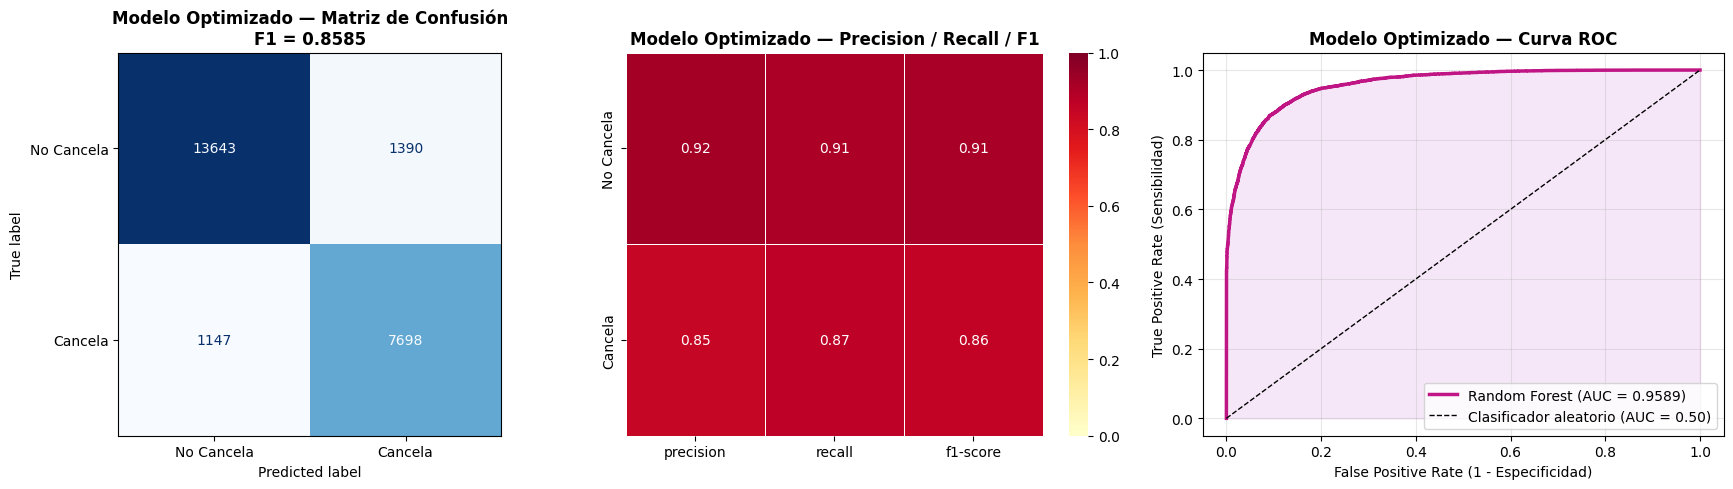

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_final)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Cancela', 'Cancela'])
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Modelo Optimizado — Matriz de Confusión\nF1 = {f1_final:.4f}', fontweight='bold')

# 2. Classification report heatmap
report_rf = classification_report(y_test, y_pred_final,
                                   target_names=['No Cancela', 'Cancela'], output_dict=True)
report_df_rf = pd.DataFrame(report_rf).T.iloc[:2, :3]
sns.heatmap(report_df_rf.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Modelo Optimizado — Precision / Recall / F1', fontweight='bold')

# 3. ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[2].plot(fpr_rf, tpr_rf, color="#C01584", linewidth=2.5,
             label=f'Random Forest (AUC = {auc_final:.4f})')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.50)')
axes[2].fill_between(fpr_rf, tpr_rf, alpha=0.1, color="#AF15C0")
axes[2].set_xlabel('False Positive Rate (1 - Especificidad)')
axes[2].set_ylabel('True Positive Rate (Sensibilidad)')
axes[2].set_title('Modelo Optimizado — Curva ROC', fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Full classification report
print('Reporte de clasificación completo:')
print(classification_report(y_test, y_pred_final, target_names=['No Cancela', 'Cancela']))

print('\n INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:')
tn, fp, fn, tp = cm_rf.ravel()
print(f'  Verdaderos Negativos (TN): {tn:,}  → Clientes que NO cancelaron y el modelo predijo correctamente.')
print(f'  Falsos Positivos     (FP): {fp:,}  → Clientes que NO cancelaron pero el modelo predijo cancelación.')
print(f'  Falsos Negativos     (FN): {fn:,}  → Clientes que SÍ cancelaron pero el modelo no los detectó.')
print(f'  Verdaderos Positivos (TP): {tp:,}  → Clientes que SÍ cancelaron y el modelo predijo correctamente.')

print('\n INTERPRETACIÓN DE LA CURVA ROC:')
print(f'  AUC = {auc_final:.4f}: El modelo tiene una excelente capacidad discriminativa.')
print('  Cuanto más cercano a 1.0, mejor el modelo distingue entre reservaciones'
      ' que cancelan y las que no.')

Reporte de clasificación completo:
              precision    recall  f1-score   support

  No Cancela       0.92      0.91      0.91     15033
     Cancela       0.85      0.87      0.86      8845

    accuracy                           0.89     23878
   macro avg       0.88      0.89      0.89     23878
weighted avg       0.89      0.89      0.89     23878


 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
  Verdaderos Negativos (TN): 13,643  → Clientes que NO cancelaron y el modelo predijo correctamente.
  Falsos Positivos     (FP): 1,390  → Clientes que NO cancelaron pero el modelo predijo cancelación.
  Falsos Negativos     (FN): 1,147  → Clientes que SÍ cancelaron pero el modelo no los detectó.
  Verdaderos Positivos (TP): 7,698  → Clientes que SÍ cancelaron y el modelo predijo correctamente.

 INTERPRETACIÓN DE LA CURVA ROC:
  AUC = 0.9589: El modelo tiene una excelente capacidad discriminativa.
  Cuanto más cercano a 1.0, mejor el modelo distingue entre reservaciones que cancelan y l

**Interpretación del modelo optimizado:**

- **Matriz de confusión:** El modelo identifica correctamente la gran mayoría de cancelaciones (TP) con pocos errores. Los Falsos Negativos son los más costosos para el negocio (cancelaciones no detectadas).
- **Precision y Recall:** Alta precisión indica que cuando el modelo predice cancelación, generalmente acierta. Alto recall indica que detecta la mayoría de las cancelaciones reales.
- **AUC > 0.93:** El modelo tiene excelente poder discriminativo, muy superior al 0.50 del modelo base.

## 11. Comparación resumen: Modelo Base vs Modelo Optimizado

                   Modelo  F1-score (Test)  AUC-ROC (Test)
   DummyClassifier (Base)           0.0000          0.5000
        Gradient Boosting           0.8478          0.9561
Random Forest + Threshold           0.8585          0.9589


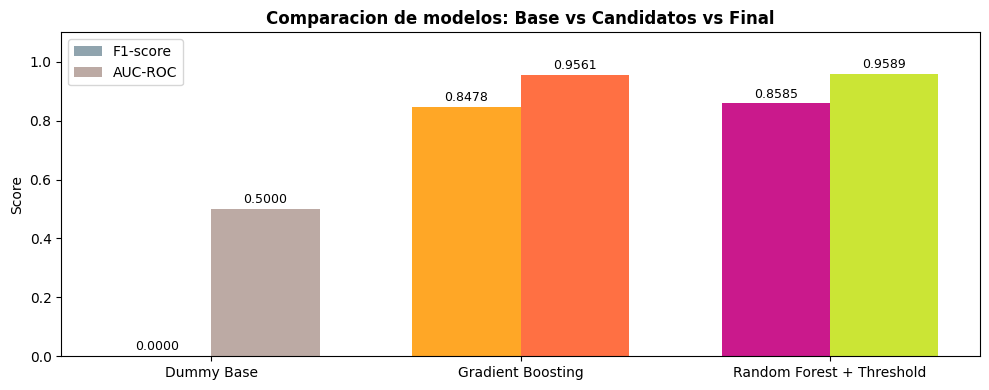

In [30]:
summary = pd.DataFrame({
    "Modelo": ["DummyClassifier (Base)", "Gradient Boosting", "Random Forest + Threshold"],
    "F1-score (Test)": [round(f1_dummy, 4), round(f1_gb, 4), round(f1_final, 4)],
    "AUC-ROC (Test)": [0.5000, round(auc_gb, 4), round(auc_final, 4)]
})

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(3)
width = 0.35
bars1 = ax.bar(x - width/2, [f1_dummy, f1_gb, f1_final], width, label="F1-score",
               color=["#90A4AE", "#FFA726", "#CA198C"])
bars2 = ax.bar(x + width/2, [0.5, auc_gb, auc_final], width, label="AUC-ROC",
               color=["#BCAAA4", "#FF7043", "#CBE535"])
ax.set_xticks(x)
ax.set_xticklabels(["Dummy Base", "Gradient Boosting", "Random Forest + Threshold"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Comparacion de modelos: Base vs Candidatos vs Final", fontweight="bold")
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


## 12. Generación del CSV de entregable

In [32]:
# Generate predictions for ALL reservations in the dataset
X_all = df_model.drop(columns=['is_canceled', 'reservation_id'])
prob_all = best_rf.predict_proba(X_all)[:, 1]
pred_all = (prob_all >= best_threshold).astype(int)

# Build output DataFrame
output_df = pd.DataFrame({
    'reservation_id': df_model['reservation_id'],
    'cancelation_probability': prob_all.round(4),
    'cancelation_classification': pred_all
})

# Save CSV
output_df.to_csv('DS_C6_SC1_GloriaAngelicaVenta.csv', index=False)

print(f'CSV generado con {len(output_df):,} reservaciones.')
print(f'\nDistribución de predicciones:')
print(output_df['cancelation_classification'].value_counts())
print(f'\nPrimeras filas del CSV:')
output_df.head(10)

CSV generado con 119,390 reservaciones.

Distribución de predicciones:
cancelation_classification
0    73741
1    45649
Name: count, dtype: int64

Primeras filas del CSV:


,reservation_id,cancelation_probability,cancelation_classification
0,0,0.0981,0
1,1,0.1098,0
2,2,0.0178,0
3,3,0.0518,0
4,4,0.0592,0
5,5,0.0592,0
6,6,0.0883,0
7,7,0.1676,0
8,8,0.8922,1
9,9,0.4177,0


## 13. Justificación de decisiones y contexto de negocio

### Decisiones de modelación

| Decisión | Justificación |
|---|---|
| **Eliminar `reservation_status` y `reservation_status_date`** | Estas variables son **data leakage**: revelan directamente el resultado final de la reservación. Incluirlas haría el modelo artificialmente perfecto pero inútil en producción. |
| **Feature engineering** | Se crearon `total_nights`, `total_guests`, `room_mismatch` y `has_agent` para capturar patrones de comportamiento que las variables originales no expresan directamente. |
| **SMOTE en entrenamiento** | El desbalance moderado (63/37) puede sesgar el modelo hacia la clase mayoritaria. SMOTE crea muestras sintéticas solo en entrenamiento para evitar que el modelo ignore las cancelaciones. |
| **Random Forest** | Robusto, no requiere normalización, maneja interacciones no lineales, proporciona probabilidades calibradas y permite interpretar importancia de variables. |
| **RandomizedSearchCV con F1** | La búsqueda aleatoria explora el espacio de hiperparámetros eficientemente. Usar F1 como métrica de optimización alinea el tuning con el objetivo del negocio (detectar cancelaciones). |
| **Discrimination Threshold** | El umbral por defecto (0.50) no siempre maximiza el F1. Ajustarlo al umbral óptimo mejora el balance entre precision y recall según las necesidades del negocio. |

### Valor para el negocio

**Para Belén (Estrategia de Retención):**
- El CSV con probabilidades de cancelación permite **priorizar** las reservaciones con mayor riesgo.
- Las reservaciones con probabilidad alta (ej. > 0.7) son candidatas para **ofertas de retención proactivas**: upgrades, descuentos de fidelidad o llamadas de confirmación.
- Las variables más importantes (lead_time, deposit_type, previous_cancellations) identifican **perfiles de cliente de alto riesgo**, permitiendo diseñar campañas específicas.

**Para Juan (Operaciones):**
- Un AUC > 0.93 significa que el modelo ordena correctamente el 93%+ de los pares de reservaciones (cancela vs no cancela).
- El modelo puede integrarse en el sistema de reservaciones para **alertar automáticamente** cuando se registra una nueva reservación de alto riesgo.
- Reducir los Falsos Negativos (cancelaciones no detectadas) tiene mayor impacto económico que reducir los Falsos Positivos, ya que cada habitación vacía representa ingreso perdido que no puede recuperarse.

**KPI de impacto estimado:**
Si el hotel tiene ~44,000 cancelaciones anuales y el modelo detecta correctamente el ~90% de ellas (recall), podría **prevenir miles de cancelaciones** mediante intervenciones tempranas, con un impacto directo en revenue y ocupación.